In [9]:

!pip install --upgrade lalsuite -i https://mirrors.aliyun.com/pypi/simple

Looking in indexes: https://mirrors.aliyun.com/pypi/simple


In [12]:
!rm -rf ./checkpoints_cnn/

loss 0.0088, train acc 0.900, test acc 0.960
438.9 examples/sec on cuda


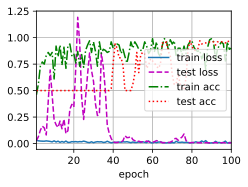

In [13]:

from main import *
from utils import *
# 初始化数据生成 class
nsample_perepoch = 100  # 每个epoch的样本数
dataset_train = DatasetGenerator(snr=20, nsample_perepoch=nsample_perepoch)  # 训练数据集
dataset_test = DatasetGenerator(snr=20, nsample_perepoch=nsample_perepoch)  # 测试数据集

# 创建一个DataLoader
data_loader = DataLoader(dataset_train, batch_size=32, shuffle=True,)  # 训练数据加载器
test_iter = DataLoader(dataset_test, batch_size=32, shuffle=True,)  # 测试数据加载器

device = torch.device('cuda')  # 使用CUDA设备

# 模型和损失历史的输出路径
checkpoint_dir = './checkpoints_cnn/'

# 创建模型
net, epoch, train_loss_history = load_model(checkpoint_dir)  # 加载模型
net.to(device);  # 将模型转移到设备上

# 优化器参数
lr = 0.003  # 学习率
total_epochs = 100  # 总的训练轮数
total_epochs += epoch  # 加上已经训练过的轮数
output_freq = 1  # 输出频率

# 训练模型
train(net, lr, nsample_perepoch, epoch, total_epochs,
      dataset_train, data_loader, test_iter,
      train_loss_history, checkpoint_dir, device, notebook=True)

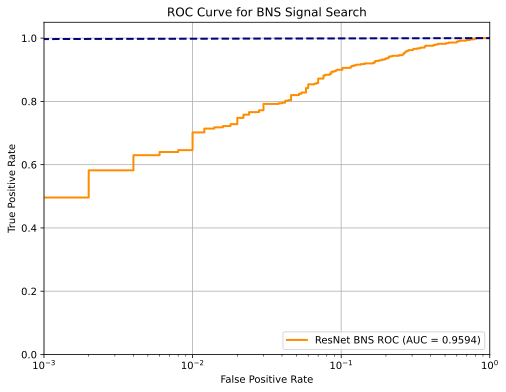

In [15]:
import torch.nn.functional as F
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# 1. 临时生成 1000 个样本用于画图，自动覆盖之前的设置
nsample_test = 1000
dataset_test.generate(nsample_test)
test_iter = DataLoader(dataset_test, batch_size=32, shuffle=True)

# 2. 模型开始测试
net.eval()
all_labels = []
all_probs = []

with torch.no_grad():
    for X, y in test_iter:
        X = X.to(device).to(torch.float)
        y = y.to(device).to(torch.long)
        y_hat = net(X)
        probs = F.softmax(y_hat, dim=1)[:, 1] # 获取是中子星信号的概率
        all_labels.extend(y.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

# 3. 计算并画图
fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ResNet BNS ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xscale('log')
plt.xlim([1e-3, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for BNS Signal Search')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()